# Pool Point Network Planner
**Volume forecasting, carrier capacity planning, and delivery scheduling for a retail outbound network**

**Author:** Nana Afari
**Tools:** Python (pandas, statsmodels, matplotlib, openpyxl) and Excel (XLOOKUP, SUMIFS, PivotTables, conditional formatting)

Multi-store retailers ship from a distribution center (DC) to regional **pool points**, where freight is cross-docked onto local trucks for store delivery. The outbound analyst keeps that network running:

- forecast volume so carriers have trailers ready,
- adjust delivery schedules when stores, pool points, or carriers request changes,
- and report KPIs that show where the network is under-performing.

This notebook builds that workflow end to end for a network of one DC, 8 pool points, 4 linehaul carriers, and 136 stores, two of which open this fall.

> **Data note.** Seasonality and trend come from **real U.S. Census clothing store sales** (FRED series `MRTSSM448USN`).
> The network itself (stores, carriers, rates, service levels) is **simulated**, because real store-level shipment data is proprietary.
> Pool point cities and road miles are approximate.

In [1]:
import json
import pandas as pd
from IPython.display import Image, Markdown, display

from src import config
from src.pipeline import run

pd.set_option("display.float_format", "{:,.3f}".format)
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 200)

# Runs the full pipeline: data, simulation, forecast, capacity, scheduling, KPIs, charts.
# The Excel report is built by run_pipeline.py; here we skip rebuilding it.
r = run(make_workbook=False)
summary = r["summary"]

## 1. Demand signal from real Census data
Monthly clothing store sales become a **weekly shipment index** (1.0 = an average week). Each month's sales become a daily rate pinned to mid-month, interpolated to each retail week, and shifted one week earlier, because stores receive product about a week before it sells.

,month,sales_musd
409,2026-02-01,22418
410,2026-03-01,26690
411,2026-04-01,25869
412,2026-05-01,29282
413,2026-06-01,26295
414,2026-07-01,27951


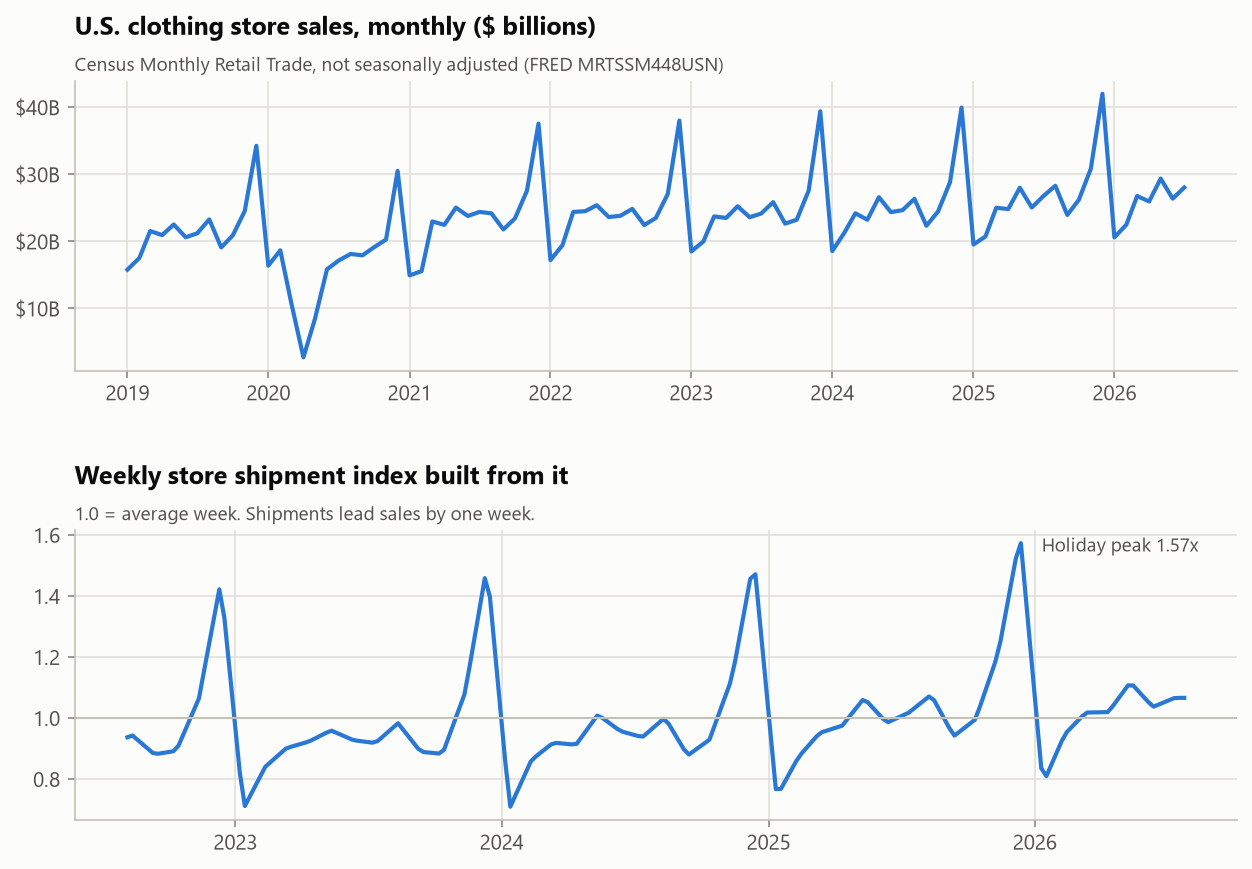

In [2]:
display(r["sales"].tail(6))
Image(config.IMAGE_DIR / "01_demand_signal.png")

## 2. The network
Each pool point is served by one linehaul carrier from the DC. Linehaul cost per trailer is the carrier's fixed charge plus miles times its rate. Contracted capacity is the 80th percentile of last year's weekly trailers plus 8% growth room.

In [3]:
cols = ["pool_point_id", "city", "state", "miles_from_dc", "carrier_id", "linehaul_cost_per_trailer",
        "contracted_trailers_per_week", "trailing_fill_pct"]
display(r["pool_points"][cols])
stores = r["stores"]
stores.groupby("pool_point_id").agg(stores=("store_id", "count"),
                                    large=("size_tier", lambda s: (s == "Large").sum()),
                                    avg_weekly_pallets=("base_weekly_pallets", "mean"),
                                    avg_pallet_max=("pallet_max", "mean"))

,pool_point_id,city,state,miles_from_dc,carrier_id,linehaul_cost_per_trailer,contracted_trailers_per_week,trailing_fill_pct
0,PP01,Albany,NY,205,CARR-A,900.250,15,0.738
1,PP02,Hartford,CT,190,CARR-A,854.500,15,0.792
2,PP03,Worcester,MA,265,CARR-B,"1,005.250",18,0.805
3,PP04,Harrisburg,PA,120,CARR-C,684.000,15,0.745
4,PP05,Pittsburgh,PA,300,CARR-C,"1,260.000",17,0.784
5,PP06,Baltimore,MD,115,CARR-D,599.250,17,0.769
6,PP07,Richmond,VA,255,CARR-D,"1,012.250",13,0.757
7,PP08,Syracuse,NY,250,CARR-B,962.500,13,0.701


,stores,large,avg_weekly_pallets,avg_pallet_max
pool_point_id,,,,
PP01,14,5,16.146,8.929
PP02,19,1,11.675,7.368
PP03,19,8,15.894,8.474
PP04,16,3,14.288,7.750
PP05,17,6,16.386,8.941
PP06,18,4,14.437,8.722
PP07,17,3,13.334,8.235
PP08,16,0,12.612,8.188


## 3. Forecast backtest
Three methods forecast weekly pallets for each pool point:

| Method | How it works |
|---|---|
| Seasonal naive | Same week last year, scaled by the last 13 weeks' year-over-year growth |
| Seasonal index | Deseasonalized level and trend times a week-of-year index. This is the version a planner can rebuild in Excel |
| Holt-Winters | Exponential smoothing with damped trend and multiplicative 52-week seasonality |

Each method forecast **26 weeks blind** from two starting points: July 2025, covering the same Aug-Jan peak season being forecast now, and January 2026. Accuracy is **WAPE**, the total absolute error divided by total actual volume.

,model,pool_point_wape,network_wape,bias
0,Holt-Winters,0.035,0.023,0.010
1,Seasonal naive,0.042,0.024,0.010
2,Seasonal index,0.042,0.032,0.028


model,Holt-Winters,Seasonal index,Seasonal naive
pool_point_id,,,
PP01,3.9%,4.9%,5.2%
PP02,2.8%,3.0%,3.2%
PP03,3.7%,4.7%,3.8%
PP04,3.1%,3.5%,3.8%
PP05,3.9%,5.1%,4.2%
PP06,4.7%,4.8%,6.4%
PP07,3.4%,3.6%,3.7%
PP08,2.4%,3.3%,2.9%


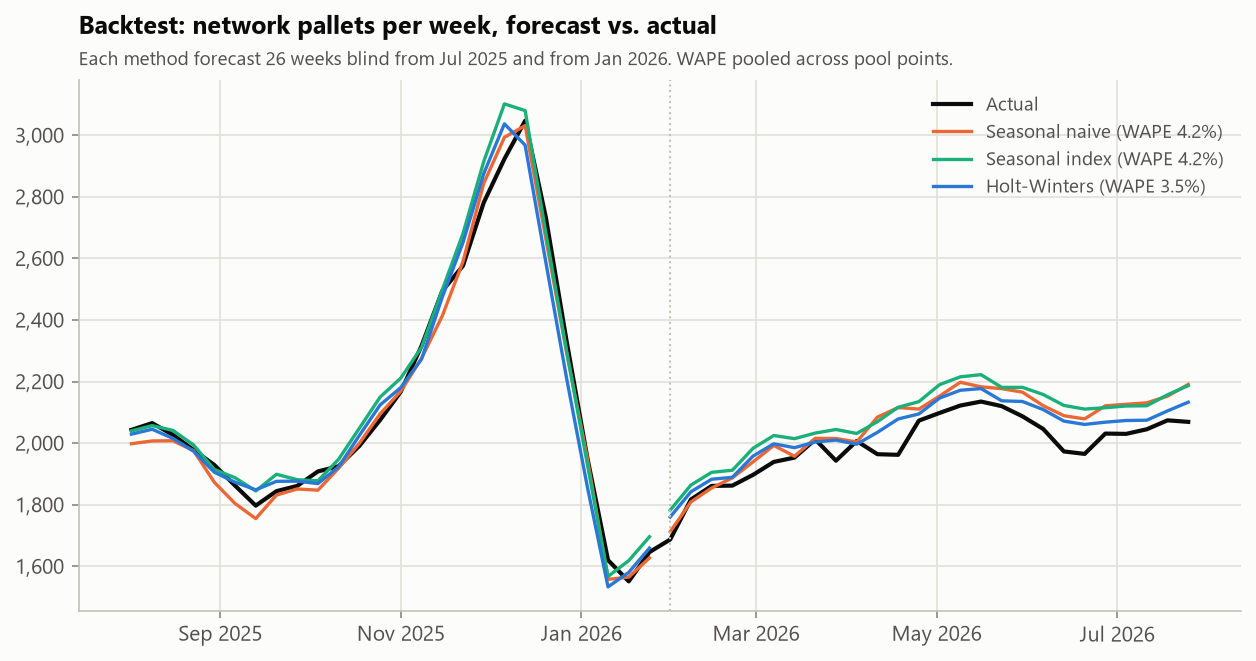

In [4]:
bt = r["backtest"]
display(bt["summary"])
display(bt["by_pool_point"].pivot(index="pool_point_id", columns="model", values="wape").style.format("{:.1%}"))
Image(config.IMAGE_DIR / "02_backtest.png")

## 4. Next 26 weeks
The winning method is refit on all 208 weeks of history. Two stores scheduled to open in September and October are added on top, with an eight-week volume ramp.

,forecast_pallets,same_weeks_last_year,yoy_change
month,,,
Aug 2026,"10,395","10,042",+3.5%
Sep 2026,"7,754","7,364",+5.3%
Oct 2026,"10,571","10,066",+5.0%
Nov 2026,"10,747","10,167",+5.7%
Dec 2026,"11,410","11,035",+3.4%
Jan 2027,"6,992","6,770",+3.3%


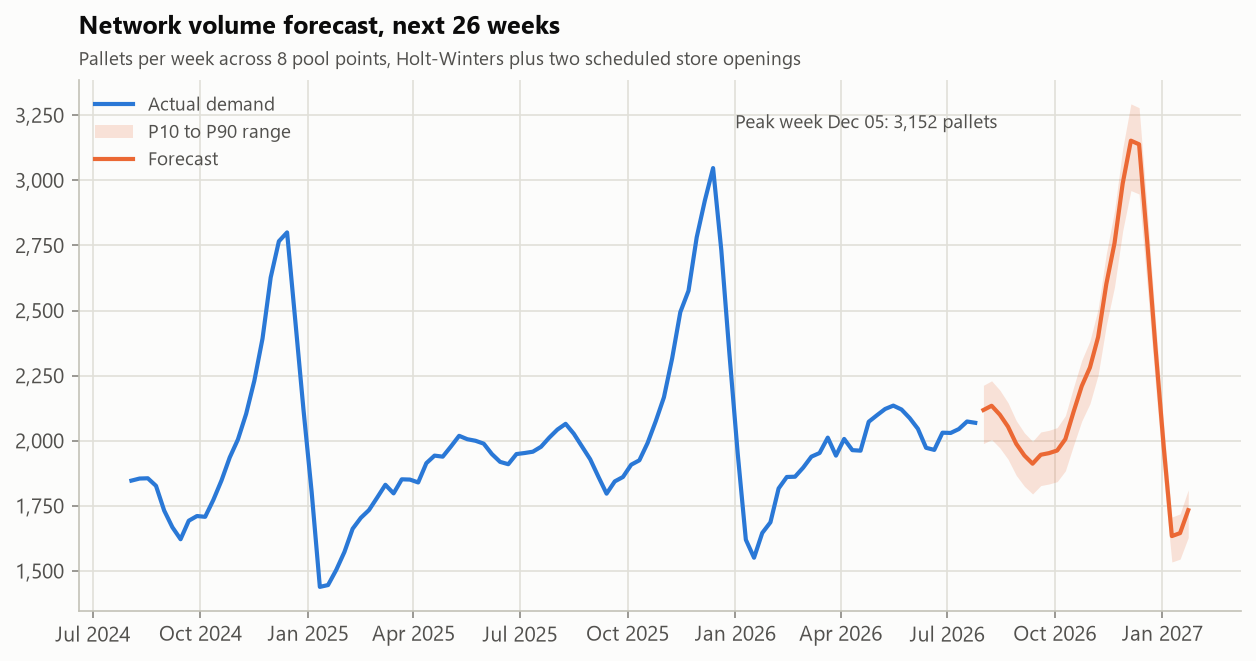

In [5]:
fc = r["network_forecast"]
history = r["series"].sum(axis=1)
# Shift history forward 52 weeks so each forecast week lines up with the same week last year
last_year = history.shift(52, freq="7D").loc[fc.index.min():fc.index.max()]
monthly = pd.DataFrame({
    "forecast_pallets": fc["forecast_pallets"].resample("MS").sum(),
    "same_weeks_last_year": last_year.resample("MS").sum(),
})
monthly["yoy_change"] = monthly["forecast_pallets"] / monthly["same_weeks_last_year"] - 1
monthly.index = monthly.index.strftime("%b %Y").rename("month")
display(monthly.style.format({"forecast_pallets": "{:,.0f}", "same_weeks_last_year": "{:,.0f}", "yoy_change": "{:+.1%}"}))
Image(config.IMAGE_DIR / "03_forecast.png")

## 5. Carrier capacity outlook
Forecast pallets become trailers using each lane's own trailing fill rate. The **high case** uses the 80th percentile of backtest error, so surge requests cover most upside without over-ordering.

Lane-weeks over contracted capacity: 53 of 208


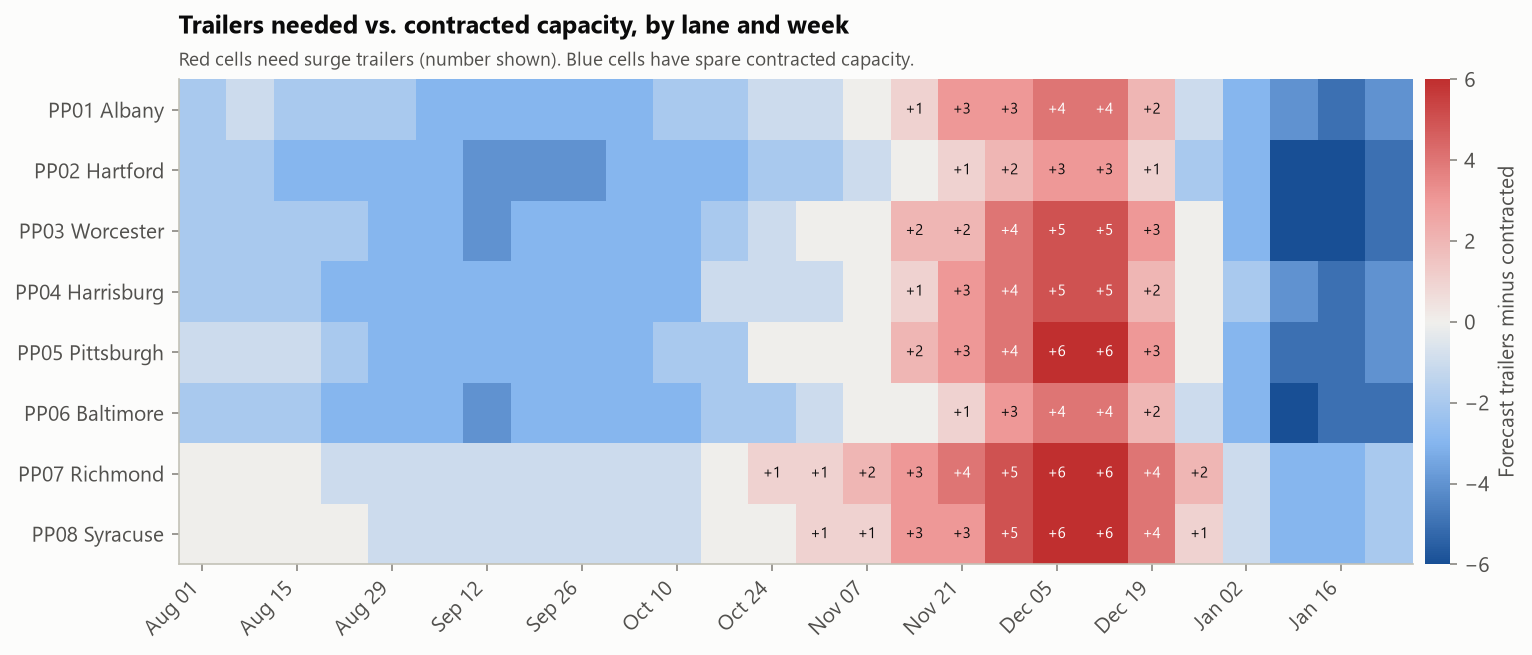

# Carrier Volume Outlook

Forecast window: weeks ending Aug 01, 2026 to Jan 23, 2027.
Trailer counts use each lane's trailing 52-week fill rate. The high case is the 80th percentile of backtest error.

## Carrier A (Albany, Hartford)

- Contracted capacity: 30 trailers per week across these lanes.
- Average forecast: 27 trailers per week, 514 pallets per week.
- Peak week: Dec 05, with 37 trailers forecast and up to 39 in the high case.
- Surge capacity needed in 6 weeks, from Nov 14 to Dec 19. Largest request: 9 extra trailers in one week.

## Carrier B (Worcester, Syracuse)

- Contracted capacity: 31 trailers per week across these lanes.
- Average forecast: 30 trailers per week, 578 pallets per week.
- Peak week: Dec 05, with 42 trailers forecast and up to 43 in the high case.
- Surge capacity needed in 10 weeks, from Oct 24 to Dec 26. Largest request: 12 extra trailers in one week.

## Carrier C (Harrisburg, Pittsburgh)

- Contracted capacity: 32 trailers per week across these lanes.
- Average forecast: 30 trailers per week, 579 pallets per week.
- Peak week: Dec 05, with 43 trailers forecast and up to 43 in the high case.
- Surge capacity needed in 8 weeks, from Nov 07 to Dec 26. Largest request: 11 extra trailers in one week.

## Carrier D (Baltimore, Richmond)

- Contracted capacity: 30 trailers per week across these lanes.
- Average forecast: 29 trailers per week, 555 pallets per week.
- Peak week: Dec 05, with 40 trailers forecast and up to 42 in the high case.
- Surge capacity needed in 10 weeks, from Oct 24 to Dec 26. Largest request: 12 extra trailers in one week.


In [6]:
lanes = r["lanes"]
print(f"Lane-weeks over contracted capacity: {summary['lane_weeks_over_capacity']} of {summary['lane_weeks_total']}")
display(Image(config.IMAGE_DIR / "04_capacity_heatmap.png"))
Markdown(r["carrier_notes"])

## 6. KPI scorecard
Each pool point is benchmarked on the trailing 52 weeks against a 95% on-time target, a 75% trailer fill target, and cost per pallet versus the network average.

,pool_point_id,city,carrier_id,avg_weekly_pallets,yoy_volume_growth,on_time_pct,on_time_status,trailer_fill_pct,fill_status,cost_per_pallet,cost_index_vs_network,cost_status,forecast_wape
0,PP01,Albany,CARR-A,241.808,0.075,0.953,Meets,0.738,Below target,80.278,0.978,In range,0.039
1,PP02,Hartford,CARR-A,239.462,0.067,0.961,Meets,0.792,Meets,84.090,1.024,In range,0.028
2,PP03,Worcester,CARR-B,323.904,0.062,0.925,Below target,0.805,Meets,87.693,1.068,In range,0.037
3,PP04,Harrisburg,CARR-C,230.173,0.085,0.972,Meets,0.745,Below target,68.831,0.839,In range,0.031
4,PP05,Pittsburgh,CARR-C,301.346,0.061,0.966,Meets,0.784,Meets,95.342,1.161,High cost,0.039
5,PP06,Baltimore,CARR-D,280.250,0.098,0.954,Meets,0.769,Meets,65.329,0.796,In range,0.047
6,PP07,Richmond,CARR-D,227.365,0.091,0.948,Below target,0.757,Meets,85.180,1.038,In range,0.034
7,PP08,Syracuse,CARR-B,217.538,0.060,0.918,Below target,0.701,Below target,87.581,1.067,In range,0.024


,carrier_id,carrier_name,lanes,avg_weekly_pallets,trailers,on_time_pct,on_time_status,trailer_fill_pct,cost_per_pallet,total_cost
0,CARR-A,Carrier A,2,481.269,1260,0.957,Meets,0.764,82.175,"2,056,502.250"
1,CARR-B,Carrier B,2,541.442,1426,0.922,Below target,0.759,87.648,"2,467,729.000"
2,CARR-C,Carrier C,2,531.519,1387,0.969,Meets,0.766,83.862,"2,317,848.250"
3,CARR-D,Carrier D,2,507.615,1330,0.951,Meets,0.763,74.220,"1,959,117.750"


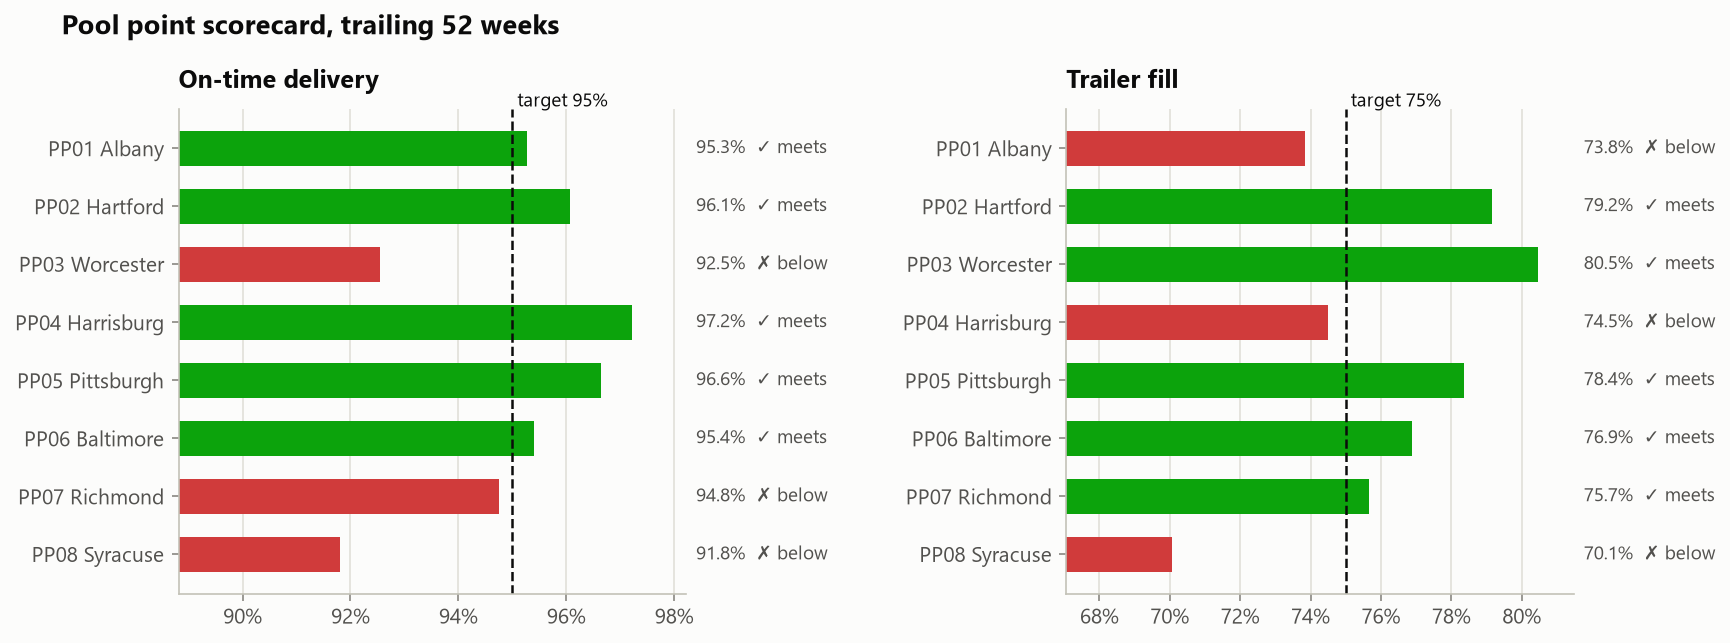

In [7]:
card = r["scorecard"]
show = ["pool_point_id", "city", "carrier_id", "avg_weekly_pallets", "yoy_volume_growth", "on_time_pct", "on_time_status",
        "trailer_fill_pct", "fill_status", "cost_per_pallet", "cost_index_vs_network", "cost_status", "forecast_wape"]
display(card[show])
display(r["carrier_scorecard"])
Image(config.IMAGE_DIR / "05_kpi_scorecard.png")

## 7. Peak week schedule and change requests
The peak forecast week is planned store by store. Each store's pallets are spread across its delivery days, and no delivery can exceed the store's **pallet max**. Pallets that don't fit roll to the next delivery, and anything left at week end is **backlog**.

Then a realistic week of change requests is applied: a pool point closure, a store cancellation, a pallet max reduction, a new store opening, and a carrier change. Each change is measured on its own, and then all together. Last, a peak mitigation plan adds a delivery day and raises the pallet max by 25% for every store with backlog. Stores that asked for smaller drops keep their pallet max.

,change_id,change_type,pool_point_id,store_id,day,old_value,new_value,reason
0,CHG-001,CANCEL_POOL_POINT_DAY,PP03,NaN,Tue,NaN,NaN,Winter storm closes the Worcester pool point f...
1,CHG-002,CANCEL_STORE_DELIVERY,PP06,S1096,Thu,NaN,NaN,Store running a physical inventory count on Th...
2,CHG-003,PALLET_MAX_CHANGE,PP01,S1001,NaN,11,7,Backroom at capacity; store asks for smaller d...
3,CHG-004,NEW_STORE,PP04,S1137,NaN,NaN,10,New store added to the network with grand-open...
4,CHG-005,CARRIER_CHANGE,PP08,NaN,NaN,CARR-B,CARR-D,Syracuse lane awarded to a new carrier


,change_id,change_type,backlog_change,deliveries_change,trailers_change,cost_change,notes
0,CHG-001,CANCEL_POOL_POINT_DAY,89,-10,-4,"-6,927.750",All Tue deliveries at PP03 cancelled; pallets ...
1,CHG-002,CANCEL_STORE_DELIVERY,7,-1,-1,-842.500,S1096 skips Thu; its pallets roll to the next ...
2,CHG-003,PALLET_MAX_CHANGE,12,0,0,-114.000,S1001 pallet max 11 to 7 per delivery.
3,CHG-004,NEW_STORE,6,2,0,475.000,S1137 added to PP04 on Tue/Fri with 26 opening...
4,CHG-005,CARRIER_CHANGE,0,0,0,455.000,Lane cost $962 to $998 per trailer; carrier on...


,scenario,deliveries,pallets_delivered,backlog_pallets,stores_with_backlog,trailers,trailer_fill_pct,linehaul_cost,total_cost,cost_per_pallet
0,1. Baseline plan,325,2700,457,133,131,0.793,"120,055.250","200,907.000",74.410
1,2. With change requests,316,2612,571,134,126,0.797,"115,890.000","193,952.750",74.250
2,3. With peak mitigation,450,3172,11,1,142,0.859,"130,254.000","236,468.500",74.550


Stores given an extra delivery day: 134
Stores whose pallet max was raised: 133


,store_id,pool_point_id,delivery_days,pallet_max,forecast_pallets,planned_pallets,backlog_pallets
0,S1001,PP01,Tue/Thu/Fri/Sat,7,38.900,28,11


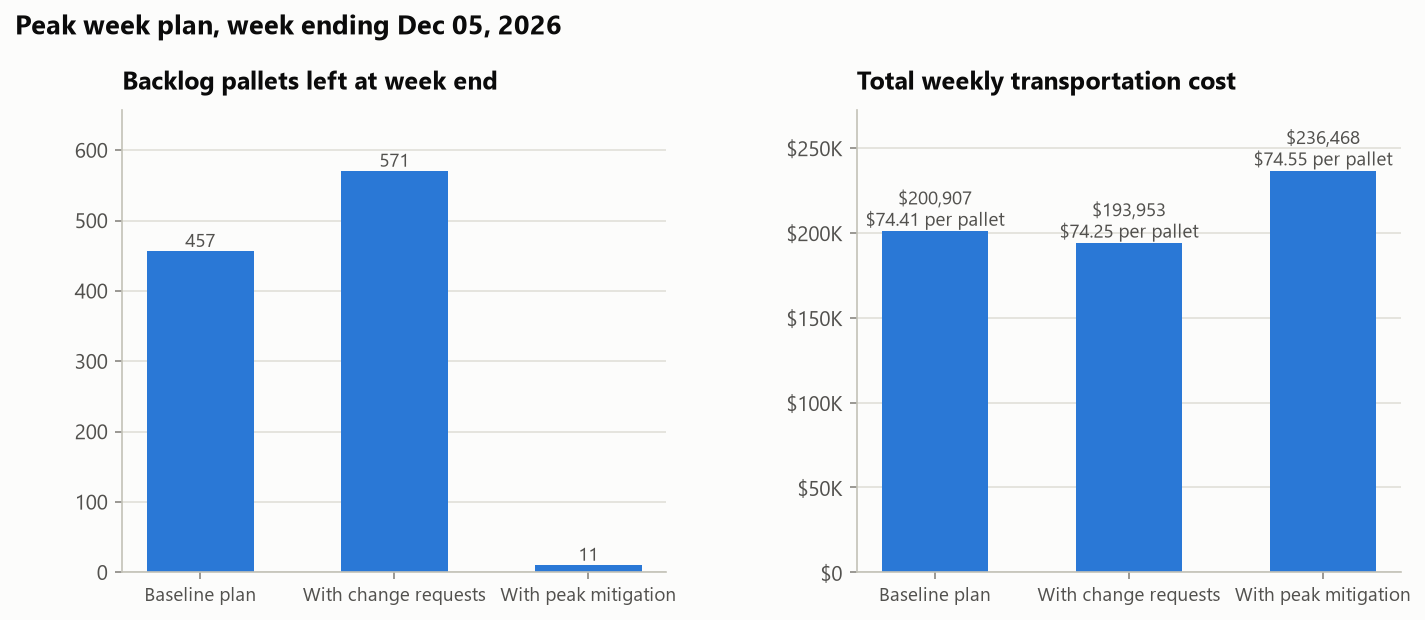

In [8]:
plan = r["plan"]
display(r["changes"][["change_id", "change_type", "pool_point_id", "store_id", "day", "old_value", "new_value", "reason"]])
display(plan["per_change"])
display(plan["scenarios"])
actions = plan["mitigation_actions"]
print(f"Stores given an extra delivery day: {(actions['added_delivery_day'] != '').sum()}")
print(f"Stores whose pallet max was raised: {(actions['pallet_max_after'] > actions['pallet_max_before']).sum()}")
left = plan["store_visibility"].query("backlog_pallets > 0")
display(left[["store_id", "pool_point_id", "delivery_days", "pallet_max", "forecast_pallets", "planned_pallets", "backlog_pallets"]])
Image(config.IMAGE_DIR / "06_schedule_scenarios.png")

## 8. Findings and recommendations

**Forecast**
- Holt-Winters had the lowest error: **3.5% WAPE** at the pool point level, versus 4.2% for both simpler methods, and 2.3% for the network total. Simulated store-level noise is cleaner than real life, so expect real-world error to be higher.
- The next 26 weeks total **57,869 pallets, up 4.4%** on the same weeks last year. Peak week is **Dec 5 at 3,152 pallets**, 3.5% above last year's peak.

**Carrier capacity**
- **53 of 208 lane-weeks** need more trailers than contracted. All of them fall between late October and late December.
- Carriers B and D need the most help, with up to **12 extra trailers in a single week**. The outlook notes should go to carriers by early October so they can source drivers and equipment.

**KPI scorecard**
- **Syracuse (PP08) is the weakest lane:** 91.8% on-time and 70.1% trailer fill, both below target.
- Carrier B misses the on-time target on both of its lanes. Pittsburgh (PP05) costs 16% more per pallet than the network average because it is the longest lane, at 300 miles.

**Peak week (week ending Dec 5)**
- Standard pallet maxes leave **457 pallets undelivered at 133 stores**, about 14% of demand. Peak volume needs a peak schedule.
- The change requests add 114 more backlog pallets. The Worcester storm closure alone adds 89.
- The peak plan **clears 98% of backlog**. Total cost rises 22% because 21% more pallets move, but **cost per pallet stays flat** ($74.55 vs $74.25) and trailer fill improves from 79.7% to 85.9%.
- One store (S1001) still carries 11 pallets because it asked for smaller drops. That calls for a conversation with store operations about a fifth delivery or a later catch-up.
- Moving Syracuse to Carrier D costs $36 more per trailer, but that carrier's on-time rate is 95.1% versus 92.2%.

## 9. Excel operations report
`outputs/pool_point_operations_report.xlsx` packages all of this for a planner:
- **Dashboard:** pick a pool point and every KPI, the 26-week forecast, and the trailer chart update (XLOOKUP, SUMIFS).
- **Volume Forecast, Carrier Outlook:** trailers needed and capacity status are live formulas tied to the Settings sheet.
- **Store Visibility, Peak Week Schedule, Backlog, Schedule Changes:** the store-facing operating reports.
- **KPI Scorecard:** status formulas against named targets, with conditional formatting.
- **Pivot Volume, Pivot On-Time:** PivotTables on the weekly history, including a weighted on-time calculated field.